- Carregando csv e importando bibliotecas

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv(r"Dados_Limpos\receita_limpa.csv")
df.head()

,mes_ref,codigo,descricao,valor
0,janeiro,1.3.2.1.01.0.1.001,REC REM OUTR DEP DE REC NÃO VINCULADA,8979.07
1,janeiro,1.6.1.1.01.0.1.018,TARIFAS DE DISPOSIÇÃO DE RESIDUOS CONSTR.CIVIL,19260.00
2,janeiro,1.6.1.1.01.0.1.007,TARIFA ESGOTO REFERENTE POÇO,0.00
3,janeiro,9.6.1.1.01.0.1.006,DESCONTOS SOCIAIS ESGOTO,0.00
4,janeiro,1.6.1.1.01.0.1.006,TARIFS UTIL. ESGOTO SANITARIO,618.39


- Receita total por mes
- Qual mes arrecadou mais e qual mes arrecadou menos

In [5]:
receita_mes = df.groupby("mes_ref")["valor"].sum().sort_values(ascending=False)

# ordenar do maior para o menor
receita_mes = receita_mes.sort_values(ascending=False)

# formatar com ponto nos milhares e decimal
receita_mes_formatado = receita_mes.map(
    lambda x: f"{x:,.2f}".replace(",", ".")
)

print(receita_mes_formatado)

mes_ref
dezembro     42.952.092.67
agosto       40.585.069.07
março        40.524.651.38
outubro      39.750.778.22
abril        39.188.060.05
fevereiro    35.856.438.90
julho        33.114.712.72
maio         31.825.427.28
janeiro      31.777.932.59
setembro     31.124.867.31
novembro     30.952.798.56
junho        30.371.449.32
Name: valor, dtype: str


- Crescimento mês a mês

In [ ]:
ordem_meses = [
    "janeiro", "fevereiro", "março", "abril",
    "maio", "junho", "julho", "agosto",
    "setembro", "outubro", "novembro", "dezembro"
]

# receita por mês
receita_mes = df.groupby("mes_ref")["valor"].sum()

# forçar ordem correta
receita_mes = receita_mes.reindex(ordem_meses)

# calcular crescimento
crescimento = receita_mes.pct_change()

# formatar %
crescimento_formatado = crescimento.map(
    lambda x: f"{x*100:.2f}%" if pd.notnull(x) else "0.00%"
)

print(crescimento_formatado)

mes_ref
janeiro        0.00%
fevereiro     12.83%
março         13.02%
abril         -3.30%
maio         -18.79%
junho         -4.57%
julho          9.03%
agosto        22.56%
setembro     -23.31%
outubro       27.71%
novembro     -22.13%
dezembro      38.77%
Name: valor, dtype: str


- Grafico de crescimento

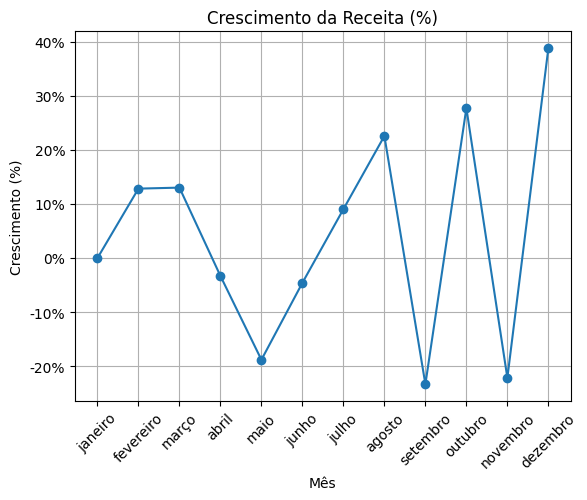

In [20]:
import matplotlib.pyplot as plt

ordem_meses = [
    "janeiro", "fevereiro", "março", "abril",
    "maio", "junho", "julho", "agosto",
    "setembro", "outubro", "novembro", "dezembro"
]

receita_mes = df.groupby("mes_ref")["valor"].sum()
receita_mes = receita_mes.reindex(ordem_meses)

crescimento = receita_mes.pct_change().fillna(0)

plt.figure()

plt.plot(crescimento.index, crescimento.values, marker="o")

plt.title("Crescimento da Receita (%)")
plt.xlabel("Mês")
plt.ylabel("Crescimento (%)")

plt.grid()


plt.xticks(rotation=45)

# eixo em %
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")

plt.show()

- Maiores Receitas, de onde vem o dinheiro

In [ ]:
# agrupar
top_receitas = df.groupby("descricao")["valor"].sum()

# ordenar descrescente
top_receitas = top_receitas.sort_values(ascending=False)

# pegar top 10 depois de ordenar
top10 = top_receitas.head(10)

# formatar bonito
top10_formatado = top10.map(
    lambda x: f"{x:,.2f}".replace(",", ".")
)

print(top10_formatado)

descricao
Cota-Parte do ICMS - Principal                        65.261.920.90
Imposto sobre Serviços de Qualquer Natureza - ISSQ    60.778.130.07
Cota-Parte do Fundo de Participação dos Municípios    50.769.032.59
TRANSF FUNDO DE MANUTENÇÃO - FUNDEB                   49.941.825.27
Cota-Parte do IPVA - Principal                        16.297.219.81
ALIENAÇÃO DE BENS IMOVEIS                             15.723.425.02
IMPOSTOS S/PREDIAL URBANO                             12.414.453.79
REC REM OUTR DEP DE REC NÃO VINCULADA                 12.384.971.43
Contribuição Patronal-Serv. Civil Ativo-Prefeitura    11.948.482.40
Imposto sobre a Renda - Retido na Fonte - Trabalho    10.498.346.35
Name: valor, dtype: str
